<a href="https://colab.research.google.com/github/pras73/soma-gen/blob/main/Copy_of_Foodhub_Data_Analysis_by_PrasannaDharmavarapu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***FoodHub Data Analysis Project by Prasanna Dharmavarapu***

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
#!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 plotly -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# reading food hub data from foodhub_order.csv file on my google drive
foodhub_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Week3_Exploratory_Data_Analysis/foodhub_order.csv')
foodhub_data

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


In [ ]:
# reading the first 5 rows of foodhub data
foodhub_data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# printing number of rows and columns in the Data
num_rows = foodhub_data.shape[0]
num_columns = foodhub_data.shape[1]
print(f'There are {num_rows} rows and {num_columns} columns in the Dataset.')

There are 1898 rows and 9 columns in the Dataset.


#### Observations:

There are 1898 rows and 9 columns in the Dataset.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Checking Datatypes of different columns in the dataset
# we can use info() function to look at summary of the structure of Dataset or we can use dtypes if we would like to check only the datatypes of the different columns
foodhub_data.info()
foodhub_data.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


,0
order_id,int64
customer_id,int64
restaurant_name,object
cuisine_type,object
cost_of_the_order,float64
day_of_the_week,object
rating,object
food_preparation_time,int64
delivery_time,int64


#### Observations:

1.There are total of 5 numerical columns in the Data, out of which (order_id,customer_id,food_preparation_time,delivery time) are of integer datatype and cost_of_order column is of float datatype.

2.There are 4 columns of object type(String) namely (restaurant_name,cuisine_type,day_of_the_week and rating) in the Data.

3.But according to problem statement, rating is given by the customer out of 5 which should be a numerical with max range of 5 but I see that rating column is read as object datatype instead of numerical data type,so need to analyze 'rating' column further before converting the column to numerical.


###### **Analyzing the 'rating' column to figure out why 'rating' column is showing as Object Datatype as opposed to Numeric Datatype**

In [ ]:
# checking value counts in rating column
foodhub_data['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations

1. There are 5 unique values ('Not given','5','4','3') in 'rating' column which is of string datatype, that explains why the column is showing as object datatype.

2. There are 736 rows in Dataset with no rating provided by Customers.

3. To address this to align with Problem statement Description, will convert Datatype of column to numeric and replace 'Not given' values with NaN (not a number).

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

#### **Comment:**

Before checking for missing values in data, we need to convert 'Not given' values in 'rating' column to NaN(Not a number).

In [ ]:
# replacing the 'Not given' values in 'rating' column with nan
foodhub_data['rating'] = foodhub_data['rating'].replace(['Not given'],np.nan)
print(foodhub_data['rating'].unique())

[nan '5' '3' '4']


#### **Comment**

All the 'Not given' values have been changed to NaN but the other 3 unique values are showing as String not numeric, will be converting the Datatype of 'rating' column to numeric in the next step.

#### **Converting the datatype of 'rating' column to numeric**

In [ ]:
# change the 'rating' column datatype to numerical instead of string, I am changing datatype to float as rating can be of float or int
foodhub_data['rating'] = foodhub_data['rating'].astype(float)
foodhub_data.dtypes

,0
order_id,int64
customer_id,int64
restaurant_name,object
cuisine_type,object
cost_of_the_order,float64
day_of_the_week,object
rating,float64
food_preparation_time,int64
delivery_time,int64


### **Checking for missing values in data**

In [ ]:
# check for missing values in the entire data
print(foodhub_data.isnull().sum())

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64


#### Observations:

Now we see that only missing values are seen in 'rating' column which are not really missing values in data, it shows clearly that 736 customers have not provided 'rating' on the orders hence the values are entered in Data as 'Not given'.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# checking statistical summary of data, for easier look and read applying transpose method
foodhub_data.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
rating,1162.0,4.344234e+00,0.741478,3.00,4.00,5.00,5.000000e+00,5.00
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:

1. cost_of_order:

   Minimum cost of the order - $4.47
   
   Average cost of the order - $16.49
   
   Maximum cost of the order - $35.41

2. **food_preparation_time:**

   Minimum food preparation time - 20 mins

   Average food preparation time - 27 mins

   Maximum food preparation time - 35 mins

3. delivery_time:

   Minimum delivery time - 15 mins

   Average delivery time - 24 mins

   Maximum delivery time - 33 mins

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# checking orders with no rating, values with NaN(not a number)
num_rows_no_rating = foodhub_data['rating'].isnull().sum()
print(f'There are {num_rows_no_rating} orders that has not been rated by Customers.')


There are 736 orders that has not been rated by Customers.


#### Observations:

There are 736 orders that has not been rated by Customers.



### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### **Exploring Numerical columns (cost_of_the_order,food_preparation_time,delivery_time) using plotly package**


       cost_of_the_order  food_preparation_time  delivery_time
count        1898.000000            1898.000000    1898.000000
mean           16.498851              27.371970      24.161749
std             7.483812               4.632481       4.972637
min             4.470000              20.000000      15.000000
25%            12.080000              23.000000      20.000000
50%            14.140000              27.000000      25.000000
75%            22.297500              31.000000      28.000000
max            35.410000              35.000000      33.000000


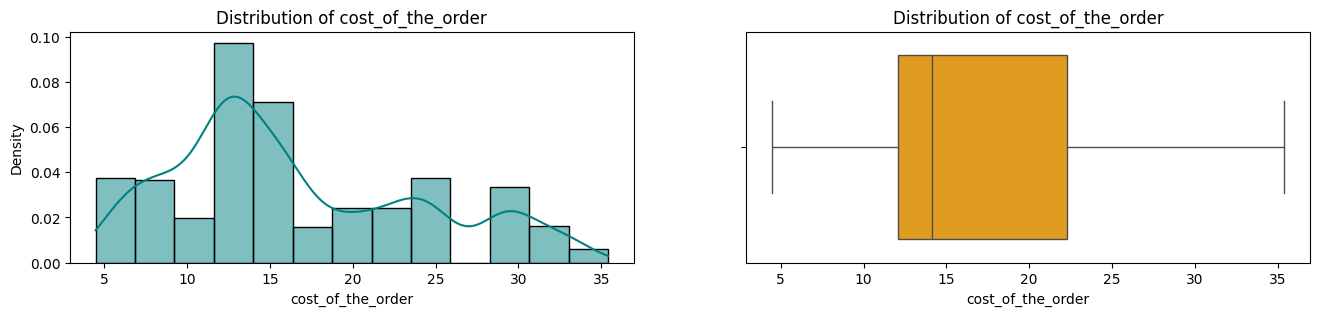

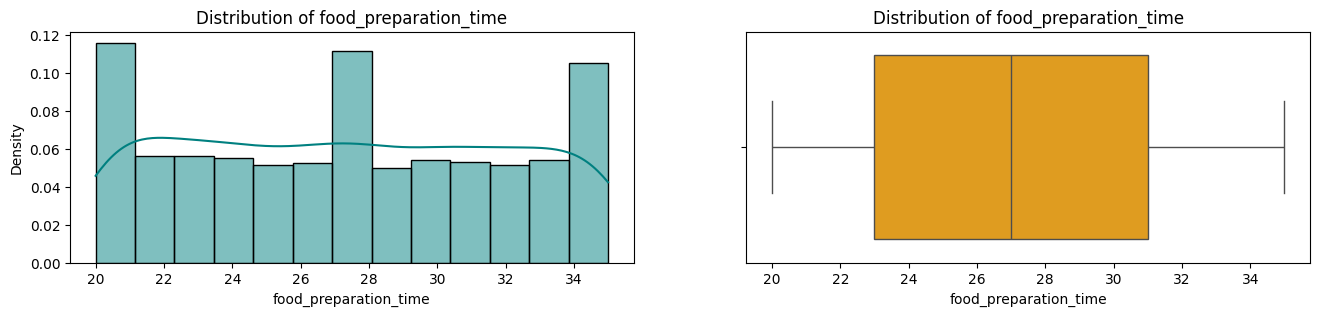

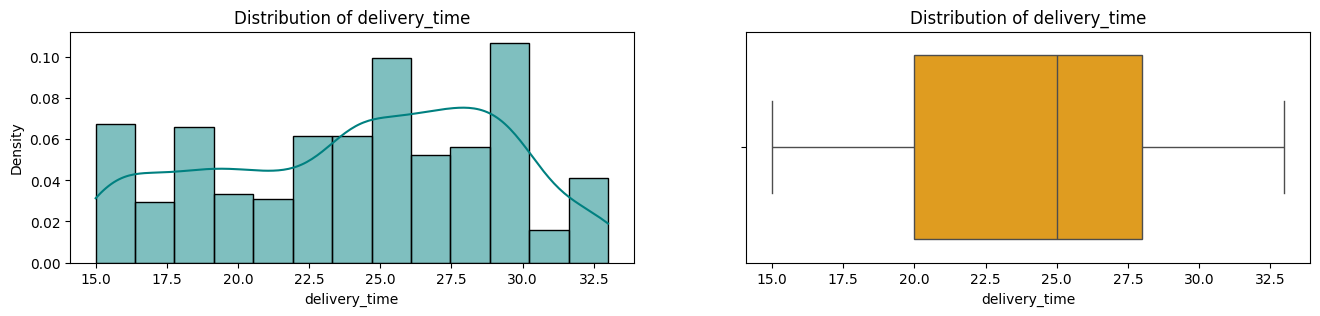

In [ ]:
'''
defining a list for  ['cost_of_the_order','food_preparation_time','delivery_time'] for analysis,not listing order_id and customer_id columns as
individually they do not provide us any useful information to analyze.

'''
# analyzing patterns of ['cost_of_the_order','food_preparation_time','delivery_time']
foodhub_num_cols = ['cost_of_the_order','food_preparation_time','delivery_time']
# statistical summary of columns
print(foodhub_data[foodhub_num_cols].describe())
# using for loop to loop through numerical columns to display histograms and boxplots side by side using subplots
for col in foodhub_num_cols:
  fig, axs = plt.subplots(1, 2, figsize=(16, 3))
  sns.histplot(x=foodhub_data[col], bins = 13, color = 'teal', kde=True, ax=axs[0], stat= 'density')
  axs[0].set_title(f'Distribution of {col}')
  sns.boxplot(x=foodhub_data[col], color= 'orange', ax=axs[1])
  axs[1].set_title(f'Distribution of {col}')
  plt.show()

#### **Observations on cost_of_order:**

* Distribution of cost_of_the_order is slightly right skewed, looking close to multimodal distribution.

* Approximately 23% of data points fall between 11 dollars and 13 dollars and 14% of data points fall between 15 dollars and 17 dollars.

* Min, mean and max for cost_of_order are approximately 4.47 dollars,16.49 dollars and 35.41 dollars respectively.

#### **Observations on food_preparation_time:**

* For food_preparation_time there is a spike in the interval's, 26.8 mins-28.2 mins,33.8 mins-35 mins.

* Approximatelt 25% of data points lie in intervals 20 mins-21.3 mins,27 mins-28.2 mins,33.8 mins-35 mins.

* Min, mean and max for food_preparation_time are approximately 20 mins,27.37 mins and 35 mins respectively.

#### **Observations on delivery_time:**

* For delivery_time there is a spike in the interval's, 24.8 mins-26.2 mins,29 mins-30 mins.

* Approximatelt 12% of data points lie in intervals 29 mins-30 mins

* Min, mean and max for delivery_time are approximately 15 mins,24.16 mins and 33 mins respectively.



#### **Exploring categorical columns (restaurant_name,cuisine_type,rating) using plotly package**

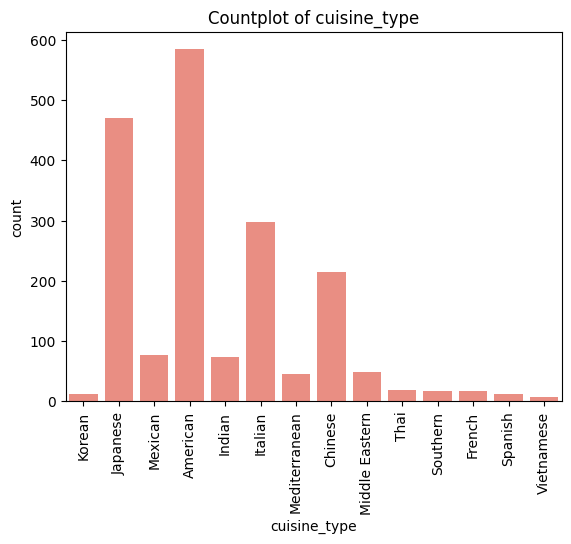

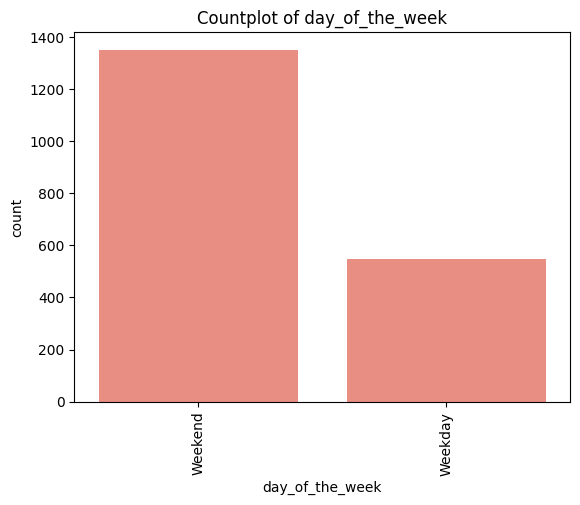

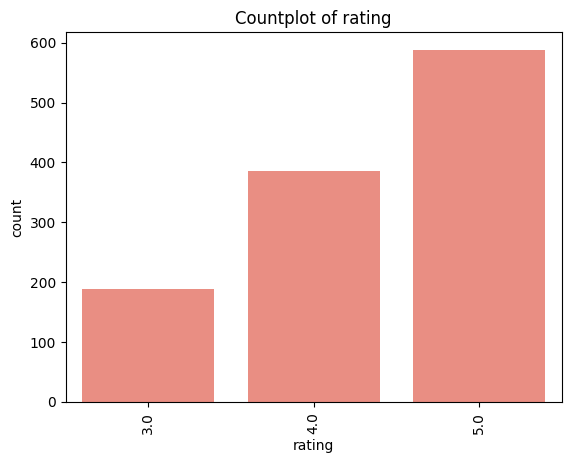

In [ ]:
#Analyzing categorical columns (cuisine_type,day_of_the_week,rating) using countplot
foodhub_cat_cols = ['cuisine_type', 'day_of_the_week', 'rating']
for col in foodhub_cat_cols:
  sns.countplot(data=foodhub_data,x=col,color='salmon')
  plt.title(f'Countplot of {col}')
  plt.xticks(rotation=90)
  plt.show()

#### **Observations on cuisine_type:**

American Cuisine is the most popular cuisine.Thai,Southern,French,Spanish and Vietnamese seems to have very few instances in the Dataset.

#### **Observations on day_of_the_week:**

Weekend Order's occurrences are more compared to Weekday Order's in the Dataset.75% of Order's are ordered over the weekend.

#### **Observations on rating:**

There are 736 Order's not rated by the Customer's in the Dataset. There are more order's rated 5 than rated 4 and rated 3.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Checking top 5 restaurants in terms of the number of orders received
top_five_res = foodhub_data["restaurant_name"].value_counts().head()
print(f"Top 5 Restaurants with respect to number of order's received are:\n{top_five_res}\n")

# plotting bar graph using plotly package
bar_topfive_res = px.bar(top_five_res, x=top_five_res.index, y=top_five_res.values, title="Top 5 Restaurants with respect to number of order's received",
                         color=top_five_res.index)
bar_topfive_res.update_layout(title_x=0.5, xaxis_title="Restaurant name", yaxis_title="Number of order's received")
bar_topfive_res.show()


Top 5 Restaurants with respect to number of order's received are:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64



#### Observations:

*  Top 5 Restaurants with respect to number of order's received are
Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm.

*  Shake Shack received 219, The Meatball Shop received 132, Blue Ribbon Sushi received 119, Blue Ribbon Fried Chicken received 96 and Parm received 68 order's respectively.




### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Most popular cuisine on weekends with count

filtered_weekend_pop_cuisine = foodhub_data[foodhub_data['day_of_the_week'] == 'Weekend'].value_counts('cuisine_type').idxmax()
popular_cuisine_count = foodhub_data[foodhub_data['day_of_the_week'] == 'Weekend'].value_counts('cuisine_type').max()
print(f'{filtered_weekend_pop_cuisine} cuisine is the most popular with {popular_cuisine_count} rows in the Dataset.')

weekend_cuisine_counts = foodhub_data[foodhub_data['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().reset_index()
weekend_cuisine_counts.columns = ['cuisine_type', 'order_count']

# Create a Plotly bar chart
bar_pop_cusine = px.bar(weekend_cuisine_counts, x='cuisine_type', y='order_count', title='Most Popular Cuisine on Weekends', color='cuisine_type')

bar_pop_cusine.update_layout(title_x=0.5, xaxis_title='Cuisine Type', yaxis_title='Number of Orders',xaxis_tickangle=-45)
bar_pop_cusine.show()

# Adding annotation for the most popular cuisine
bar_pop_cusine.add_annotation(
    x=filtered_weekend_pop_cuisine,
    y=popular_cuisine_count,
    text=f"Most Popular: {filtered_weekend_pop_cuisine} ({popular_cuisine_count} orders)",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60,
    bgcolor="yellow",
    bordercolor="black",
    borderwidth=1,
    font=dict(size=12, color="black")
)

bar_pop_cusine.show()



American cuisine is the most popular with 415 rows in the Dataset.


#### Observations:

Most popular cuisine on weekend is American Cuisine with 415 rows in the Dataset.



### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
#checking percentage of order's costing more than 20 dollars
foodhub_data['orders_cost_more_20'] = foodhub_data['cost_of_the_order'] > 20
data = foodhub_data['orders_cost_more_20'].value_counts(normalize=True).mul(100).reset_index()
data.columns = ['Order_cost_comparison', 'Percentage']
data['Order_cost_comparison'] = data['Order_cost_comparison'].map({True: 'Orders cost more than $20' , False: 'Orders cost less than $20'})
print(data.loc[1,['Order_cost_comparison', 'Percentage']])
# plotting bar graph using plotly package
bar_cost_comp = px.bar(data, x='Order_cost_comparison', y='Percentage', title="Percentage of the order's cost more than $20",
                         color='Order_cost_comparison')
bar_cost_comp.update_layout(title_x=0.5, xaxis_title="Cost comparison", yaxis_title="Percentage of order's")
bar_cost_comp.show()

# Get the percentage for orders costing more than $20 for annotation
percentage_more_than_20 = data.loc[data['Order_cost_comparison'] == 'Orders cost more than $20', 'Percentage'].values[0]

# Adding annotation for the most popular cuisine
bar_cost_comp.add_annotation(
    x='Orders cost more than $20', # X-coordinate of the annotation (category name)
    y=percentage_more_than_20,    # Y-coordinate of the annotation (the percentage value)
    text=f"{percentage_more_than_20:.2f}%", # Text to display, formatted to two decimal places
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-30, # Adjust vertical offset for better placement above the bar
    bgcolor="yellow", # Light background for the text box
    bordercolor="black",
    borderwidth=1,
    font=dict(size=12, color="black")
)
bar_cost_comp.show()

Order_cost_comparison    Orders cost more than $20
Percentage                               29.241307
Name: 1, dtype: object


#### Observations:

29.24% of the order's cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# checking the mean order delivery time
avg_delivery_time = foodhub_data['delivery_time'].mean()
print(f"Mean order delivery time is {round(avg_delivery_time,2)} minutes.")

Mean order delivery time is 24.16 minutes.


#### Observations:

Mean order delivery time is 24.16 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# count the number of orders for each customer
cus_order_count = foodhub_data['customer_id'].value_counts().reset_index()
cus_order_count.columns = ['customer_id', 'order_count']

# top 3 most frequent customers
top_3_customers = cus_order_count.head(3)
display(top_3_customers)


# Create a Plotly bar chart to display the top 3 customers
bar_top_3 = px.bar(top_3_customers, x='customer_id', y='order_count',
    title='Top 3 Most Frequent Customers', color='customer_id')
bar_top_3.update_layout(title_x=0.5,xaxis_title='Customer ID', yaxis_title='Number of Orders', xaxis_tickangle=-45)

# Add annotations for each of the top 3 customers, using for loop to count from second row
for _, row in top_3_customers.iterrows():
    bar_top_3.add_annotation(
        x=row['customer_id'],
        y=row['order_count'],
        text=f"ID: {row['customer_id']} made {row['order_count']} Order's",
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-60,
        bgcolor="lightblue",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=10, color="black")
    )
bar_top_3.show()


,customer_id,order_count
0,52832,13
1,47440,10
2,83287,9


#### Observations:

*   Customer ID's of top 3 most frequent Customers are 52832, 47440, 83287

*   Total of 32 order's were placed by top 3 most frequent Customers




### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### **Performing analysis on Cost_of_order and cuisine_type columns using boxplot**

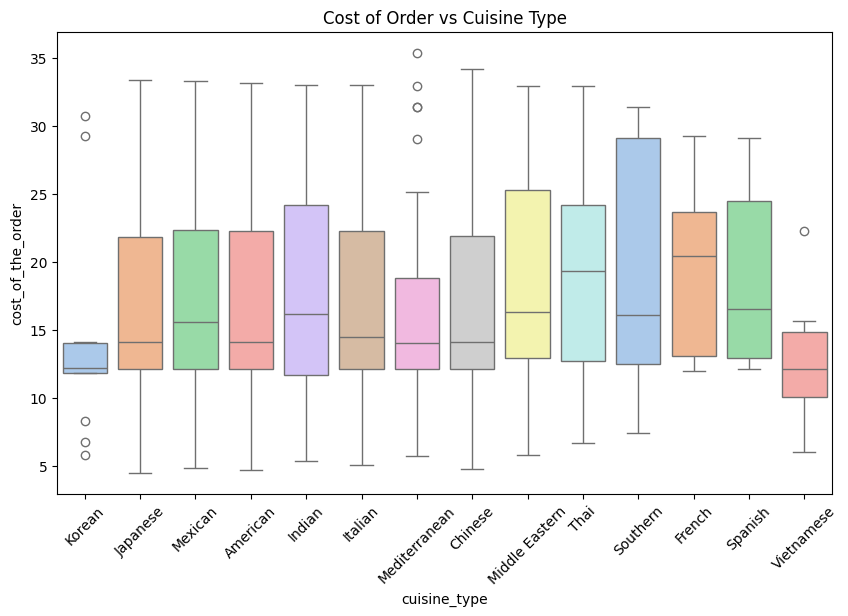

In [ ]:
# Performing analysis on Cost_of_order and cuisine_type columns using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=foodhub_data, x='cuisine_type', y='cost_of_the_order', hue='cuisine_type', palette='pastel')
plt.title('Cost of Order vs Cuisine Type')
plt.xticks(rotation=45)
plt.show()

#### Observations:

* Minimum cost for French and Spanish cuisine is approximately 12 dollars which is higher than minimum cost of other cuisines.They are costly min price starting at 12 dollars.

* 5 number stats(min,25%,mean,75%,max) of American,Italian,Japanese and Mexican looks similar just very slight variations in average cost on each one.

* Korean,Meditteranean cuisine and Vietnamese cost less than other cuisines and have outliers.Korean Cuisine plot has outliers on both the ends, Meditteranean cuisine and Vietnamese cuisine are right skewed.



#### **Performing analysis on cuisine_type and food_preparation_time columns using boxplot**

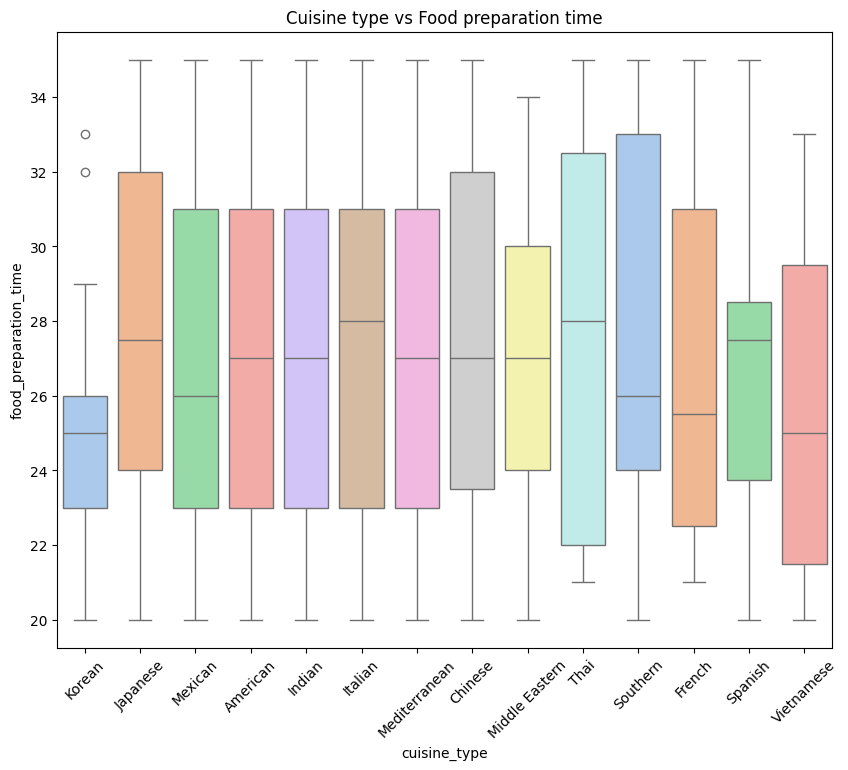

In [ ]:
# Performing analysis on cuisine_type and food_preparation_time columns using boxplot
plt.figure(figsize=(10,8))
sns.boxplot(data=foodhub_data, x='cuisine_type', y='food_preparation_time', hue='cuisine_type', palette='pastel')
plt.title('Cuisine type vs Food preparation time')
plt.xticks(rotation=45)
plt.show()

#### Observations:

* Average food preparation time looks almost the same for American,Indian,Meditteranean,Chinese and Middle Eastern.

* Food preparation time 5 number stats(min,25%,mean,75%,max) is the same for American,Indian,Italian,Meditteranean and Mexican except for slight variation in average food preparation time for Mexican and Italian.

* There are outliers for food preparation time for Korean cuisine, it could be there were few resources to prepare food and it took longer time than max.

* Average food preparation time for Italian,Thai and Spanish cuisines seems to be higher compared to other cuisines.


#### **Performing analysis on day_of_the_week and delivery time columns using boxplot**

<Figure size 1000x600 with 0 Axes>

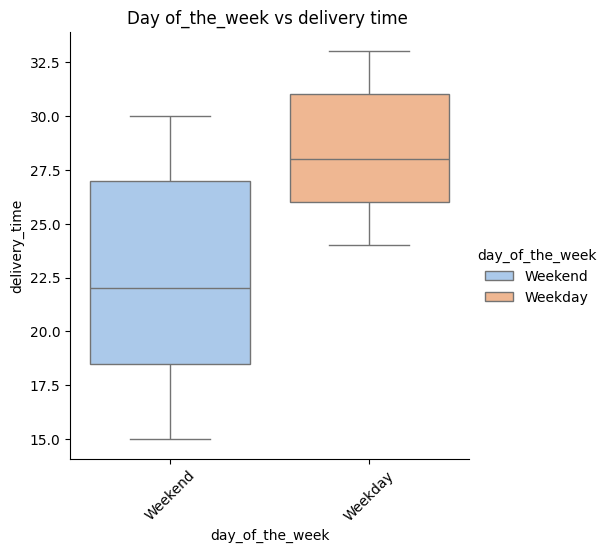

In [ ]:
# Performing analysis on day_of_the_week and delivery time columns using histplot
plt.figure(figsize=(10, 6))
sns.catplot(data=foodhub_data, x='day_of_the_week', y='delivery_time', kind='box', hue='day_of_the_week', palette='pastel', legend=True)
plt.title('Day of_the_week vs delivery time ')
plt.xticks(rotation=45)
plt.show()

#### Observation:

* Delivery time is taking longer on weekdays than weekends, could be various possibilities high traffic on weekdays due to work commutes,school etc or it could be there are more resources(people,delivery methods) on weekends to handle delivery.

* Min time for delivery on weekends is 15 mins and on weekdays it is approximately 26 mins.

* Max time for delivery on weekends is 30 mins and on weekdays it is approximately 33 mins.

* Mean delivery time for delivery on weekends is 22 mins and on weekdays it is approximately 28 mins.




### **Analysis on columns cuisine_type, cost_of_the_order, day_of_the_week in the Dataset.**

In [ ]:
foodhub_data_avg_cost = foodhub_data.groupby(['cuisine_type', 'day_of_the_week'])['cost_of_the_order'].mean().reset_index()

bar_avg_cost = px.bar(foodhub_data_avg_cost, x='cuisine_type', y='cost_of_the_order', color='day_of_the_week', title='Average Cost per Cuisine by Day of the Week',
             barmode='group')
bar_avg_cost.update_layout(title_x=0.5, xaxis_title='cuisine_type', yaxis_title='cost_of_the_order', xaxis_tickangle=-45)
bar_avg_cost.show()

#### Obsevation:

* On Weekends, Average cost of Thai cuisine is highest followed by Spanish, French, Southern average costs being closer to Thai.

* On Weekdays, Average cost of French cuisine is highest followed by Middle Eastern and Southern average costs being closer to French.

* There is no much variation in Average costs of Indian, Japanese, Mexican and Southern cuisines when we compare there average costs on Weekdays and Weekends.



### **Analysis on columns cuisine_type, cost_of_the_order, rating in the Dataset.**

In [ ]:
# Plotting a box plot to explore Average Rating and cost_of_the_order by cuisine_type
foodhub_data_stats = foodhub_data.groupby('cuisine_type').agg(avg_rating=('rating', 'mean'), avg_cost=('cost_of_the_order', 'mean')).reset_index()

# Creating a bar chart for average Rating and cost_of_the_order by cuisine_type
bar_avg_cost_rating = px.bar(foodhub_data_stats, x="cuisine_type", y="avg_rating",
             color="avg_cost",
             title="Average Restaurant Rating and Cost by Cuisine Type", hover_data=['avg_cost'])
bar_avg_cost_rating.update_layout(title_x=0.5, xaxis_title='cuisine_type', yaxis_title='average_rating', xaxis_tickangle=-45)
bar_avg_cost_rating.show()

#### Observation:

* Vietnamese cuisine has lowest average rating with average rating of 4 and average cost of approximately $13.

* Average cost and Average rating of American, Chinese, Italian, Japanese and Mexican cuisines are almost the same.



### **Analysis on columns Cuisine_type, day_of_the_week, delivery_time in the Dataset.**

In [ ]:
box_cost_cuisine_deltime = px.box(foodhub_data, x='cuisine_type', y='delivery_time', color='day_of_the_week',
             title='Delivery Time by Cuisine and Day of Week',
             hover_data=['day_of_the_week'])
box_cost_cuisine_deltime.update_layout(title_x=0.5, xaxis_title='cuisine_type', yaxis_title='delivery_time', xaxis_tickangle=-45)
box_cost_cuisine_deltime.show()

#### Observation:

* Not seeing much Korean and Spanish cuisine order's delivered during Weekdays.

* 75% of Southern cuisine order's delivery time is higher than 75% of order's delivery time for other cuisine types during weekdays, indicating could be because of resource shortage for Southern cuisine on weekdays.



### **Analysis on columns cuisine_type, day_of_the_week, food_preparation_time in the Dataset.**

In [ ]:
heatmap_data = foodhub_data.pivot_table(values='food_preparation_time', index='cuisine_type', columns='day_of_the_week', aggfunc='mean')

# plotting Heatmap
fig = px.imshow(heatmap_data, x=heatmap_data.columns, y=heatmap_data.index, color_continuous_scale=px.colors.sequential.Plasma, text_auto=True,
                title="Average Food Prep Time by Cuisine and Day")

fig.update_layout(title_x=0.5, xaxis_title="Day of the Week", yaxis_title="Cuisine Type")
fig.layout.height = 700
fig.layout.width = 700
fig.show()

#### Observation:

When comparing average food preparation time for all cuisines on Weekdays and Weekends, I am not seeing much variation in average food preparation time for all cuisines except for Spanish cuisine seeing some variation, weekdays average food preparation time is higher than on weekends with a variation of 7 minutes. Could be shortage of resources.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

List of Restaurants fulfilling criteria to get promotional offer are:
                            count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     64  4.328125
Blue Ribbon Sushi             73  4.219178
Shake Shack                  133  4.278195
The Meatball Shop             84  4.511905

************************************************************************************************************************************************************************************


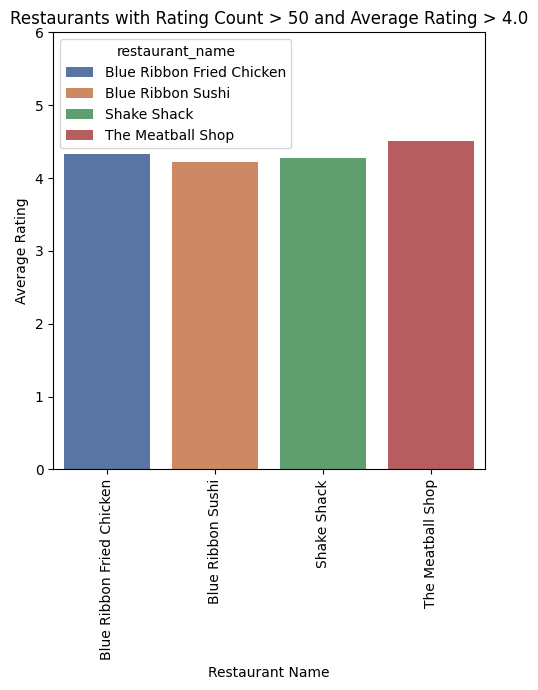

In [ ]:
# pulling restaurants fulfilling criteria's(restaurants must have rating count > 50 and average rating > 4)
res_ratings_stats = foodhub_data.groupby('restaurant_name')['rating'].agg(['count', 'mean'])
# restaurants fulfilling criteria's(restaurants must have rating count > 50 and average rating > 4)
res_criteria_fulfilled = res_ratings_stats[(res_ratings_stats['count'] > 50) & (res_ratings_stats['mean'] > 4)]
print(f"List of Restaurants fulfilling criteria to get promotional offer are:\n {res_criteria_fulfilled}\n")
print('***'*60)

# plotting bar plot for the filtered restaurants
plt.figure(figsize=(5,7))
sns.barplot(data=res_criteria_fulfilled, x='restaurant_name', y=res_ratings_stats['mean'], hue='restaurant_name', palette='deep')
plt.xticks(rotation=90)
plt.ylim(0,6)
plt.xlabel('Restaurant Name')
plt.ylabel('Average Rating')
plt.title('Restaurants with Rating Count > 50 and Average Rating > 4.0')
plt.tight_layout()
plt.show()



#### Observations:

List of Restaurants fulfilling criteria to get promotional offer are:
                              
Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack and The Meatball Shop.            

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# initializing net revenue and restaurant income to value 0
net_revenue = 0
res_income = 0

# creating a list of cost_of_order column
list_cost_of_order = foodhub_data['cost_of_the_order'].tolist()

for cost in list_cost_of_order:
  if cost > 5:
    if cost > 20:
      res_income = cost * 0.25
      net_revenue += res_income
    else:
      res_income = cost * 0.15
      net_revenue += res_income

print(f"Net revenue generated by the company across all orders is ${round(net_revenue,2)}")

Net revenue generated by the company across all orders is $6166.3


#### Observations:

Net revenue generated by the company across all orders is $6166.3


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
foodhub_data['total_time_to_deliver'] = foodhub_data['food_preparation_time'] + foodhub_data['delivery_time']
orders_filtered = foodhub_data[foodhub_data['total_time_to_deliver'] > 60]
per_orders_filtered = (orders_filtered.shape[0] / foodhub_data.shape[0]) * 100
print(f'{round(per_orders_filtered,2)}% of orders take more than 60 minutes to get delivered from the time the order is placed.')

# Create a histogram for total delivery time
fig = px.histogram(foodhub_data, x='total_time_to_deliver', nbins=30, title='Distribution of Total Order Delivery Time')

# Add a vertical line at 60 minutes to show the order's which take more than 60 minutes to deliver
fig.add_vline(x=60, line_dash='dash', line_color='red', annotation_text='60 Minutes')
fig.update_layout(title_x=0.5, xaxis_title='Total Delivery Time (minutes)', yaxis_title='Number of Orders')
fig.show()

10.54% of orders take more than 60 minutes to get delivered from the time the order is placed.


#### Observations:

10.54% of orders take more than 60 minutes to get delivered from the time the order is placed.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

### **Performing analysis on day_of_the_week and delivery time columns using boxplot**

<Figure size 1000x600 with 0 Axes>

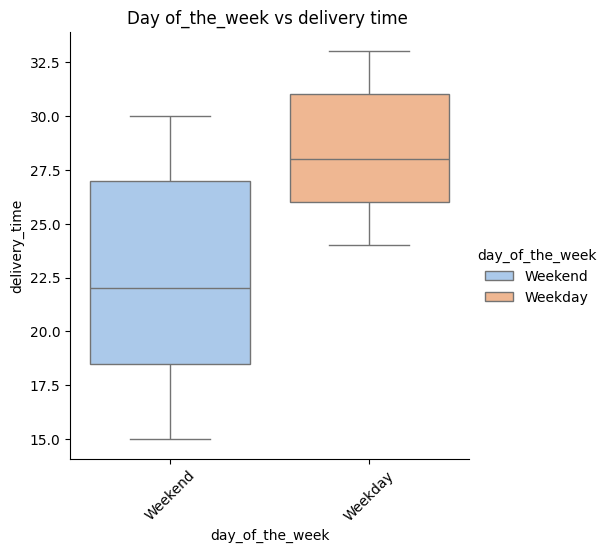

In [ ]:
# Performing analysis on day_of_the_week and delivery time columns using boxplot

plt.figure(figsize=(10, 6))
sns.catplot(data=foodhub_data, x='day_of_the_week', y='delivery_time', kind='box', hue='day_of_the_week', palette='pastel', legend=True)
plt.title('Day of_the_week vs delivery time ')
plt.xticks(rotation=45)
plt.show()

#### Observation:

* Delivery time is taking longer on weekdays than weekends, could be various possibilities high traffic on weekdays due to work commutes,school etc or it could be there are more resources(people,delivery methods) on weekends to handle delivery.

* Min time for delivery on weekends is 15 mins and on weekdays it is approximately 26 mins.

* Max time for delivery on weekends is 30 mins and on weekdays it is approximately 33 mins.

* Mean delivery time for delivery on weekends is 22 mins and on weekdays it is approximately 28 mins. Mean delivery time on Weekends is less than on Weekdays.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

* Foodhub Data has 1898 rows and 9 columns, There are 736 order's with no rating.

* 10.54% of orders take more than 60 minutes to get delivered from the time the order is placed.

* American cuisine is most popular cuisine on Weekends.

* Top 5 Restaurants with respect to number of order's received are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm.

* The Meatball Shop has the highest average rating followed by Blue Ribbon Fried Chicken and Shake Shack.

* 29.24% of orders cost more than 20 dollars.

* Net revenue generated by the company across all orders is $6166.3

* When comparing average food preparation time for all cuisines on Weekdays and Weekends, I am not seeing much variation in average food preparation time for all cuisines except for Spanish cuisine seeing some variation, weekdays average food preparation time is higher than on weekends with a variation of 7 minutes. Could be shortage of resources.

* There is no much variation in Average costs of Indian, Japanese, Mexican and Southern cuisines when we compare there average costs on Weekdays and Weekends.


### Recommendations:

* When it comes to Popular cuisine, American cuisine is the most popular especially on weekends, the company can consider partnering with more restaurants offering this cuisine or promote existing ones with some weekend deals.

* When it comes to delivery time, 10% of orders taking more than 60 mins for delivery, delivery time could be improved by increased delivery resources, better route optimization or and prioritizing orders during high peak times.

* Encourage Top Restaurants with some promotional offers.

* There are subsequent number of order's with no rating,implementing a feedback system might help in getting more customer ratings which can be help in continuous improvement as at the end of the day Customer's satisfaction is the most important which will help strengthen the Net revenue of the Company.

* Introducing Customer Loyalty Programs for those who order more than a certain number of times a month or any other criteria could help retain customer's retention and to have more consistent order count.

* Considering other factors like time of day, day of the week, and restaurant location to optimize delivery times.



---